In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Ai and Ml/Copy of FruitinAmazon.zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed successfully")

Extraction completed successfully


In [3]:
train_dir = "dataset/FruitinAmazon/train"

# Check structure
print(os.listdir("dataset"))
print(os.listdir(train_dir))

['FruitinAmazon']
['graviola', 'pupunha', 'acai', 'cupuacu', 'guarana', 'tucuma']


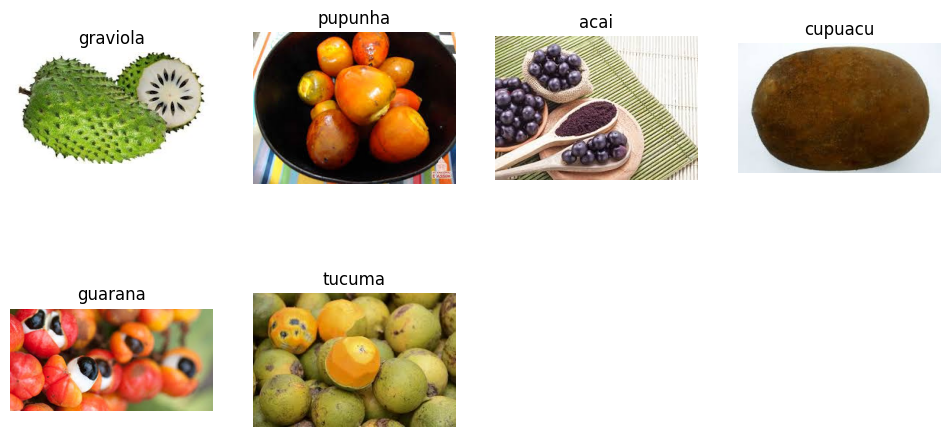

In [6]:
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = os.listdir(train_dir)

plt.figure(figsize=(12,6))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, (len(classes)//2)+1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

The dataset contains images grouped into class folders. Each folder represents a fruit category. The images vary in orientation, lighting, and background but share common visual features that help the CNN learn patterns.

In [7]:
from PIL import Image
import os

corrupted_images = []

for class_name in os.listdir(train_dir):

    class_path = os.path.join(train_dir,class_name)

    if os.path.isdir(class_path):

        for file in os.listdir(class_path):

            image_path = os.path.join(class_path,file)

            try:
                img = Image.open(image_path)
                img.verify()

            except (IOError, SyntaxError):

                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

if len(corrupted_images) == 0:
    print("No corrupted images found.")

No corrupted images found.


In [8]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

train_ds = train_ds.map(lambda x,y:(rescale(x),y))
val_ds = val_ds.map(lambda x,y:(rescale(x),y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [9]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

num_classes = len(classes)

model = Sequential([

layers.Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(128,128,3)),
layers.MaxPooling2D((2,2)),

layers.Conv2D(32,(3,3),padding='same',activation='relu'),
layers.MaxPooling2D((2,2)),

layers.Flatten(),

layers.Dense(64,activation='relu'),
layers.Dense(128,activation='relu'),

layers.Dense(num_classes,activation='softmax')

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

This CNN model is designed to classify images into 6 fruit classes. The input image of size 128×128×3 first passes through two convolutional layers (Conv2D) with 32 filters that extract important visual features such as edges, textures, and shapes from the images. Each convolution layer is followed by a MaxPooling layer, which reduces the image size and helps decrease computation while retaining important features. The Flatten layer then converts the 2D feature maps into a 1D vector so it can be processed by fully connected Dense layers (64 and 128 neurons) that learn complex patterns. Finally, the output Dense layer with 6 neurons and softmax activation produces probability values for each fruit class, and the class with the highest probability is selected as the prediction. The model has about 2.1 million trainable parameters that are optimized during training.

In [13]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

This code compiles the CNN model before training. The Adam optimizer is used to update the model’s weights efficiently during training. The sparse_categorical_crossentropy loss function is used because the problem is a multi-class classification task and the labels are given as integers rather than one-hot encoded vectors. The accuracy metric is included to measure how many predictions the model classifies correctly during training and validation.

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
"best_model.h5",
monitor='val_loss',
save_best_only=True
)

early_stop = EarlyStopping(
patience=10,
restore_best_weights=True
)

history = model.fit(
train_ds,
epochs=250,
validation_data=val_ds,
callbacks=[checkpoint,early_stop],
batch_size=16
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.1250 - loss: 1.8438

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 542ms/step - accuracy: 0.1250 - loss: 1.8526 - val_accuracy: 0.0556 - val_loss: 1.6549
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.2390 - loss: 1.6880

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 442ms/step - accuracy: 0.2639 - loss: 1.6852 - val_accuracy: 0.7778 - val_loss: 1.3044
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 381ms/step - accuracy: 0.4444 - loss: 1.4381 - val_accuracy: 0.1667 - val_loss: 1.7350
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.4444 - loss: 1.3024

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 443ms/step - accuracy: 0.4583 - loss: 1.2427 - val_accuracy: 0.6667 - val_loss: 1.0953
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.6250 - loss: 0.9952

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 451ms/step - accuracy: 0.6250 - loss: 1.0064 - val_accuracy: 0.5556 - val_loss: 0.8973
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.6858 - loss: 0.8143

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 532ms/step - accuracy: 0.6667 - loss: 0.8662 - val_accuracy: 0.7778 - val_loss: 0.7742
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.7297 - loss: 0.6747

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 707ms/step - accuracy: 0.7361 - loss: 0.6794 - val_accuracy: 0.7778 - val_loss: 0.6911
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 598ms/step - accuracy: 0.8889 - loss: 0.5031 - val_accuracy: 0.6667 - val_loss: 1.0810
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.9196 - loss: 0.4062

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 423ms/step - accuracy: 0.9306 - loss: 0.4013 - val_accuracy: 0.8333 - val_loss: 0.4141
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.9803 - loss: 0.2180

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 433ms/step - accuracy: 0.9722 - loss: 0.2247 - val_accuracy: 0.8333 - val_loss: 0.3677
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 418ms/step - accuracy: 0.9583 - loss: 0.1720 - val_accuracy: 0.8333 - val_loss: 0.4553
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 410ms/step - accuracy: 1.0000 - loss: 0.0687 - val_accuracy: 0.8333 - val_loss: 0.3997
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 423ms/step - accuracy: 1.0000 - loss: 0.0718 - val_accuracy: 0.8333 - val_loss: 0.3755
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 398ms/step - accuracy: 0.9861 - loss: 0.0388 - val_accuracy: 0.8889 - val_loss: 0.4400
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 505ms/step - accuracy: 1.0000 - loss: 0.0222 - val_accuracy: 0.8333 - val_loss: 0.3907
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 742ms/step - accuracy: 1.0000 - loss: 0.0085 - val_accuracy: 0.8333 - val_loss: 0.4100
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 399ms/step - accuracy: 1.0000 - loss: 0.0129 - val_accuracy: 0.8333 - val_lo

At the beginning (Epoch 1), the model performs poorly with low accuracy (~12%) and high loss (~1.85) because the model has not yet learned useful patterns from the images. As training continues, the accuracy gradually increases while the loss decreases, which indicates that the model is learning to classify the fruit images more correctly. By around Epoch 10–14, the training accuracy reaches almost 100%, and the validation accuracy stabilizes around 83–88%, showing that the model has learned strong features from the training data. The validation loss remains around 0.36–0.45, indicating good generalization on unseen validation images. Overall, the training results show that the model successfully learns from the dataset and achieves about 83% validation accuracy, with slight overfitting since training accuracy becomes higher than validation accuracy.

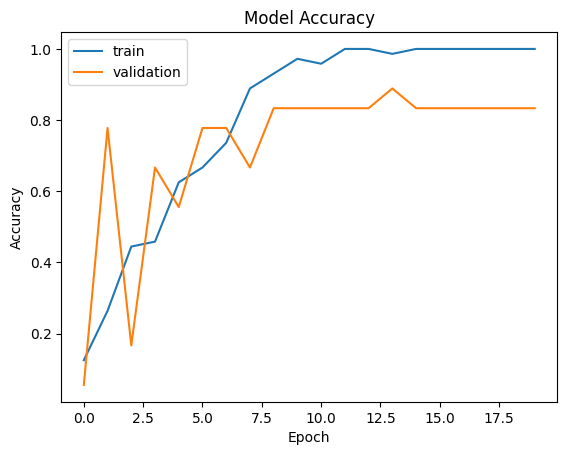

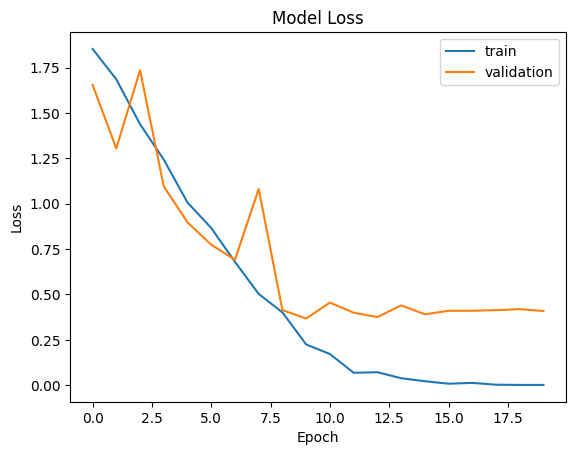

In [15]:
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='validation')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='validation')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

The accuracy graph shows that the training accuracy steadily increases and reaches nearly 100%, while the validation accuracy rises to about 83–88%. This indicates that the model successfully learns patterns from the training data and performs well on unseen validation data. However, since the training accuracy is higher than validation accuracy, there is slight overfitting.

The loss graph shows that the training loss continuously decreases and approaches zero, while the validation loss decreases initially and then stabilizes around 0.4. This indicates that the model is learning effectively during training but has a small gap between training and validation performance.Overall, the model demonstrates good learning performance with minor overfitting, achieving around 83% validation accuracy.

In [16]:
test_loss,test_acc = model.evaluate(val_ds)

print("Test Accuracy:",test_acc)
print("Test Loss:",test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8333 - loss: 0.3677
Test Accuracy: 0.8333333134651184
Test Loss: 0.3676553964614868


In [17]:
model.save("fruit_cnn_model.h5")

from tensorflow.keras.models import load_model

loaded_model = load_model("fruit_cnn_model.h5")

loss,accuracy = loaded_model.evaluate(val_ds)

print("Loaded Model Accuracy:",accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.8333 - loss: 0.3677
Loaded Model Accuracy: 0.8333333134651184


In [23]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images,labels in val_ds:

    predictions = loaded_model.predict(images)

    pred_labels = np.argmax(predictions,axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)
unique_labels = np.unique(y_true)

print(classification_report(y_true,y_pred, labels=unique_labels,target_names=[classes[i] for i in unique_labels]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
              precision    recall  f1-score   support

     guarana       1.00      0.67      0.80         3
      tucuma       0.93      0.87      0.90        15

   micro avg       0.94      0.83      0.88        18
   macro avg       0.96      0.77      0.85        18
weighted avg       0.94      0.83      0.88        18



This code generates a classification report to evaluate the performance of the trained CNN model on the validation dataset. First, two lists y_true and y_pred are created to store the actual labels and predicted labels. The loop goes through the validation dataset (val_ds) and uses loaded_model.predict() to predict the class probabilities for each batch of images. The function np.argmax() is then used to convert these probabilities into the predicted class index. The true labels are collected using labels.numpy(), and both true and predicted labels are stored in the lists. After that, np.unique(y_true) is used to find which classes actually appear in the validation dataset. Finally, classification_report() prints evaluation metrics such as precision, recall, and F1-score for each class. In your result, only guarana and tucuma appear because these are the only classes present in the validation set. The model achieves about 83% overall accuracy, with good performance for the class tucuma (F1-score ≈ 0.90).